                                                                Multiple Linear Regression 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [4]:
df=pd.read_csv("ToyotaCorolla - MLR.csv")

In [6]:
df.columns=df.columns.str.strip().str.replace(" ", "_")

In [7]:
print("Columns in dataset:")
print(df.columns)

Columns in dataset:
Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')


In [8]:
#Rename columns
df=df.rename(columns={
    "Age_08_04":"Age",
    "Fuel_Type":"FuelType"})

In [9]:
#Basic info and summary
print("\nDataset Info:")
print(df.info())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age        1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   FuelType   1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB
None


In [10]:
#Basic summary
print("\nSummary Statistics:")
print(df.describe())



Summary Statistics:
              Price          Age             KM           HP    Automatic  \
count   1436.000000  1436.000000    1436.000000  1436.000000  1436.000000   
mean   10730.824513    55.947075   68533.259749   101.502089     0.055710   
std     3626.964585    18.599988   37506.448872    14.981080     0.229441   
min     4350.000000     1.000000       1.000000    69.000000     0.000000   
25%     8450.000000    44.000000   43000.000000    90.000000     0.000000   
50%     9900.000000    61.000000   63389.500000   110.000000     0.000000   
75%    11950.000000    70.000000   87020.750000   110.000000     0.000000   
max    32500.000000    80.000000  243000.000000   192.000000     1.000000   

                cc        Doors  Cylinders        Gears      Weight  
count   1436.00000  1436.000000     1436.0  1436.000000  1436.00000  
mean    1576.85585     4.033426        4.0     5.026462  1072.45961  
std      424.38677     0.952677        0.0     0.188510    52.64112  
min  

In [11]:
#Handle missing values
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Price        0
Age          0
KM           0
FuelType     0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64


In [12]:
#Drop missing values
df=df.dropna()

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


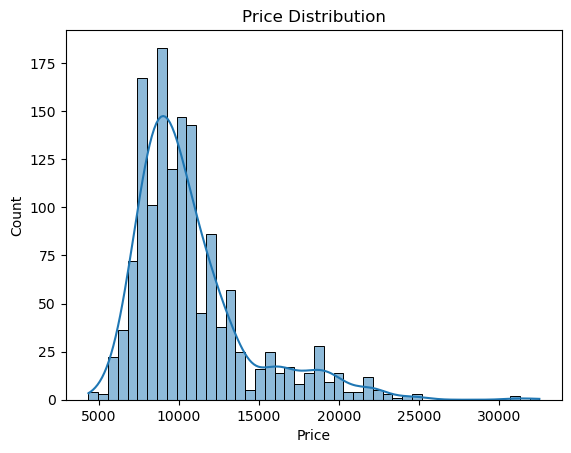

In [13]:
#EDA-Histogram
plt.figure()
sns.histplot(df["Price"], kde=True)
plt.title("Price Distribution")
plt.show()

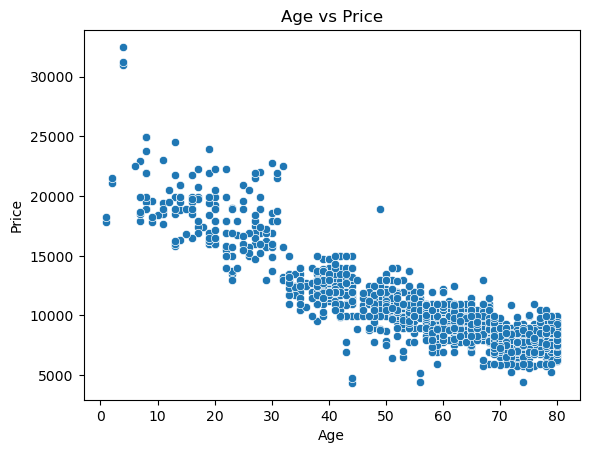

In [14]:
#Scatter plots
plt.figure()
sns.scatterplot(x=df["Age"], y=df["Price"])
plt.title("Age vs Price")
plt.show()

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


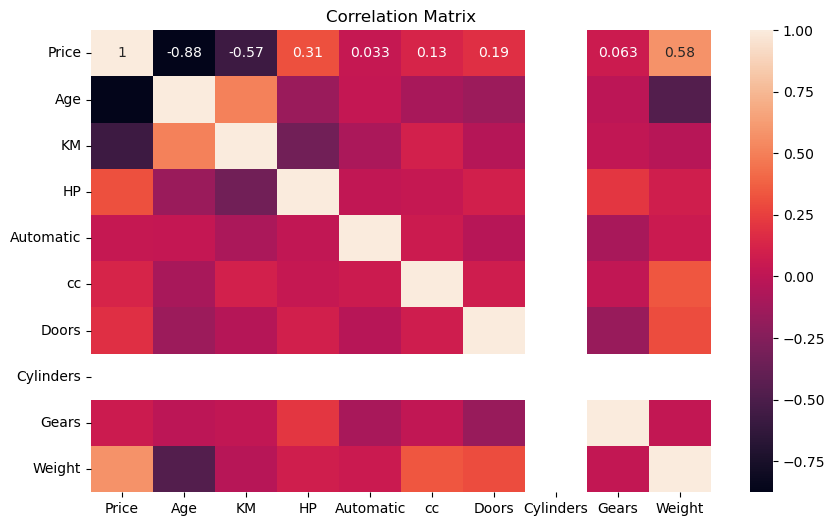

In [15]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [16]:
#convert categorical variables
df=pd.get_dummies(df, columns=["FuelType"], drop_first=True)

In [17]:
#feature & target
X=df.drop("Price", axis=1)
y=df["Price"]

In [18]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)

In [19]:
#Feature scaling
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [21]:
# Linear regression
model1=LinearRegression()
model1.fit(X_train_scaled, y_train)
y_pred1=model1.predict(X_test_scaled)
print("\nMODEL 1 Results")
print("R2 Score:",r2_score(y_test,y_pred1))
print("MSE:",mean_squared_error(y_test,y_pred1))


MODEL 1 Results
R2 Score: 0.8348888040611082
MSE: 2203043.8231437034


In [23]:
#Selected features
features=["Age", "KM", "HP", "Weight"]
X2=df[features]
X2_train,X2_test,y_train,y_test=train_test_split(
    X2,y,test_size=0.2,random_state=42)
scaler2=StandardScaler()
X2_train=scaler2.fit_transform(X2_train)
X2_test=scaler2.transform(X2_test)
model2=LinearRegression()
model2.fit(X2_train,y_train)
y_pred2=model2.predict(X2_test)

print("\nMODEL 2 Results")
print("R2 Score:",r2_score(y_test,y_pred2))
print("MSE:",mean_squared_error(y_test,y_pred2))


MODEL 2 Results
R2 Score: 0.8506068681500834
MSE: 1993321.0129727365


In [24]:
model3=LinearRegression()
model3.fit(X_train_scaled, y_train)

y_pred3=model3.predict(X_test_scaled)
print("\nMODEL 3 Results")
print("R2 Score:", r2_score(y_test,y_pred3))
print("MSE:", mean_squared_error(y_test,y_pred3))


MODEL 3 Results
R2 Score: 0.8348888040611082
MSE: 2203043.8231437034


In [25]:
#Ridge regression
ridge=Ridge(alpha=1.0)
ridge.fit(X_train_scaled,y_train)
y_pred_ridge=ridge.predict(X_test_scaled)

print("\nRidge Results")
print("R2 Score:",r2_score(y_test, y_pred_ridge))
print("MSE:",mean_squared_error(y_test, y_pred_ridge))


Ridge Results
R2 Score: 0.8350462635431568
MSE: 2200942.8745232904


In [26]:
#Lasso regression
lasso=Lasso(alpha=0.1)
lasso.fit(X_train_scaled,y_train)
y_pred_lasso=lasso.predict(X_test_scaled)

print("\nLasso Results")
print("R2 Score:", r2_score(y_test, y_pred_lasso))
print("MSE:", mean_squared_error(y_test, y_pred_lasso))


Lasso Results
R2 Score: 0.8349116135580271
MSE: 2202739.480842683


In [27]:
#Coefficient interpretation
coeff_df=pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model1.coef_})

print("\nModel Coefficients:")
print(coeff_df)


Model Coefficients:
            Feature   Coefficient
0               Age -2.267295e+03
1                KM -6.116544e+02
2                HP  2.083499e+02
3         Automatic  3.439713e+01
4                cc -1.416192e+01
5             Doors -5.746780e+01
6         Cylinders -1.705303e-13
7             Gears  1.093404e+02
8            Weight  1.316818e+03
9   FuelType_Diesel -2.172217e+01
10  FuelType_Petrol  4.580477e+02


Interview Questions

1) Normalization(Min-Max Scaling):

- Normalization rescales data into a fixed range, usually 0 to 1.

Example:
  If values range from 10 to 50, normalization converts them into values between 0 and 1.

- They are helpful in:
  Improving model performance.
  Prevents feature dominance.
  Stabilizes numerical computations.

2) Key Techniques to Address Multicollinearity:- Ridge Regression (L2 Regularization)
- Principal Component Analysis (PCA)
- Lasso Regression (L1 Regularization)
- Remove Highly Correlated Predictors
- Combine Predictors
